In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import joblib 
from sklearn.ensemble import IsolationForest
from sqlalchemy import create_engine
from urllib.parse import quote_plus # Para manejar la contraseña

# Configura matplotlib para que los gráficos se vean bien
%matplotlib inline

In [3]:
# 1. Credenciales de la Base de Datos
DB_USER = "myvolt_admin" 
DB_PASS = "M%R^N!J%IDKS$8@zya4v"
DB_HOST = "myvolt-db.postgres.database.azure.com"
DB_PORT = "5432"
DB_NAME = "postgres" 

# 2. Codificar la contraseña
DB_PASS_ENCODED = quote_plus(DB_PASS)

# 3. Crear la cadena de conexión
try:
    connection_string = f"postgresql+psycopg2://{DB_USER}:{DB_PASS_ENCODED}@{DB_HOST}:{DB_PORT}/{DB_NAME}?sslmode=require"
    engine = create_engine(connection_string)
    
    # 4. Prueba de conexión
    with engine.connect() as conn:
        print("¡Conexión a Azure PostgreSQL exitosa!")
        
except Exception as e:
    print(f"Error al conectar a Azure: {e}")

¡Conexión a Azure PostgreSQL exitosa!


In [4]:
# Consulta SQL para traer los 5000 datos más recientes
query = """
SELECT time, power_w
FROM consumption_data
WHERE id_device = (
    SELECT id_device 
    FROM devices 
    WHERE mac_address = 'B0:A7:32:34:54:9C'
)
ORDER BY time DESC
LIMIT 5000; 
"""

# Usamos Pandas para ejecutar la consulta y cargar los datos
df = pd.read_sql_query(query, con=engine)

print(f"Se cargaron {len(df)} registros (los más recientes) desde la base de datos.")
df.head()

Se cargaron 2451 registros (los más recientes) desde la base de datos.


,time,power_w
0,2025-11-07 04:13:25.980018+00:00,0.0
1,2025-11-07 04:13:25.779987+00:00,0.0
2,2025-11-07 04:13:25.581181+00:00,0.0
3,2025-11-07 04:13:25.383849+00:00,0.0
4,2025-11-07 04:13:25.187495+00:00,0.0


In [5]:
# Seleccionamos solo la columna 'power_w' para el entrenamiento
datos_para_modelo = df[['power_w']]

print("Datos listos para el modelo:")
datos_para_modelo.head()

Datos listos para el modelo:


,power_w
0,0.0
1,0.0
2,0.0
3,0.0
4,0.0


In [6]:
# 1. Inicializamos el modelo (esperamos un 10% de anomalías/ruido)
modelo_if = IsolationForest(contamination=0.1, random_state=42)

# 2. Entrenamos el modelo con nuestros datos de potencia del Foco LED
modelo_if.fit(datos_para_modelo)

print("¡Modelo entrenado exitosamente!")

¡Modelo entrenado exitosamente!


In [7]:
# 1. Pedimos al modelo que etiquete los datos: 1 (normal) o -1 (anomalía)
predicciones = modelo_if.predict(datos_para_modelo)

# 2. Guardamos las predicciones en el DataFrame
df['anomalia_predicha'] = predicciones

# 3. Revisamos qué encontró
anomalias = df[df['anomalia_predicha'] == -1]
print(f"El modelo detectó {len(anomalias)} anomalías de un total de {len(df)} registros.")

print("\nEjemplos de potencias anómalas (W) encontradas:")
print(anomalias['power_w'].value_counts().head())

El modelo detectó 164 anomalías de un total de 2451 registros.

Ejemplos de potencias anómalas (W) encontradas:
power_w
15.0    83
14.0    81
Name: count, dtype: int64


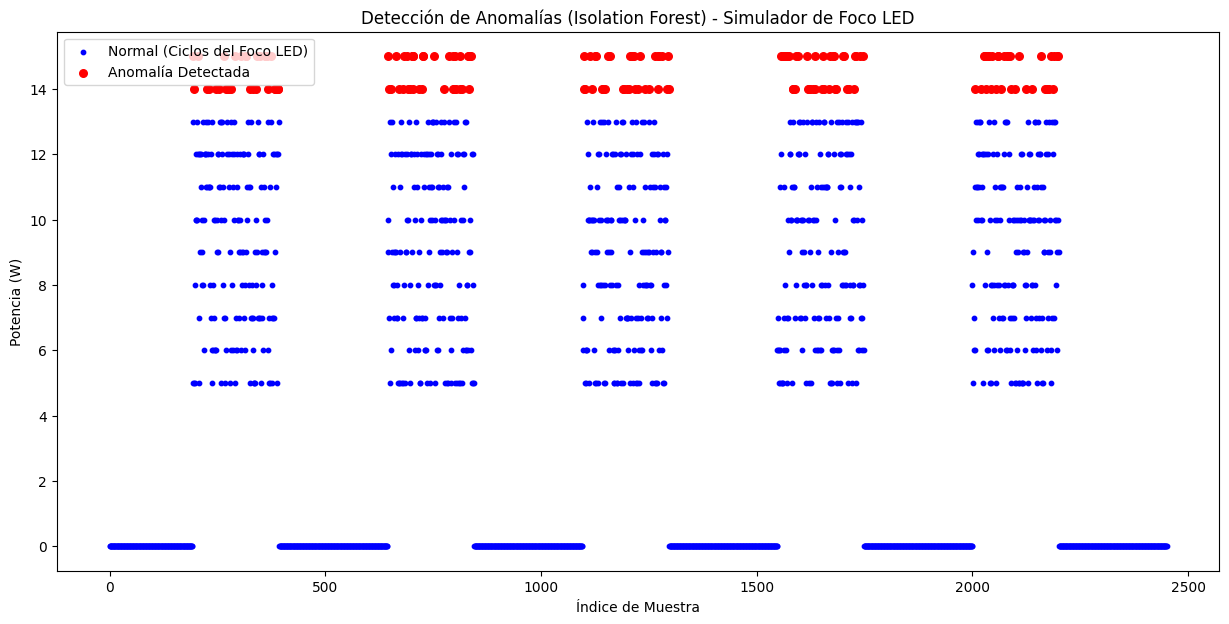

In [8]:
# Separamos los datos normales y los anómalos
df_normal = df[df['anomalia_predicha'] == 1]
df_anomalo = df[df['anomalia_predicha'] == -1]

# Creamos el gráfico
plt.figure(figsize=(15, 7))

# Pintamos los puntos normales en azul
# AHORA DEBERÍAS VER DOS LÍNEAS: una en 0W y otra entre 5-15W
plt.scatter(df_normal.index, df_normal['power_w'], 
            c='blue', label='Normal (Ciclos del Foco LED)', s=10)

# Pintamos las anomalías en rojo
plt.scatter(df_anomalo.index, df_anomalo['power_w'], 
            c='red', label='Anomalía Detectada', s=30)

plt.title('Detección de Anomalías (Isolation Forest) - Simulador de Foco LED')
plt.xlabel('Índice de Muestra')
plt.ylabel('Potencia (W)')
plt.legend()
plt.show()

In [9]:
# 1. Definimos la ruta de salida (en la carpeta 'models')
# ¡Nombra el archivo de forma específica!
ruta_modelo = '../models/models_v1/foco_led_model_v1.pkl' 

# 2. Guardamos el modelo entrenado
joblib.dump(modelo_if, ruta_modelo)

print(f"¡Modelo del FOCO LED guardado exitosamente en {ruta_modelo}!")

¡Modelo del FOCO LED guardado exitosamente en ../models/models_v1/foco_led_model_v1.pkl!
